In [5]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation --force

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0




  0%|          | 0.00/4.16G [00:00<?, ?B/s]
  0%|          | 7.00M/4.16G [00:00<01:05, 68.5MB/s]
  0%|          | 14.0M/4.16G [00:00<01:06, 67.0MB/s]
  1%|          | 24.0M/4.16G [00:00<00:58, 75.6MB/s]
  1%|          | 32.0M/4.16G [00:00<00:57, 77.7MB/s]
  1%|          | 40.0M/4.16G [00:00<00:56, 78.6MB/s]
  1%|          | 48.0M/4.16G [00:00<00:56, 78.1MB/s]
  1%|▏         | 56.0M/4.16G [00:00<00:58, 74.8MB/s]
  2%|▏         | 66.0M/4.16G [00:00<00:56, 78.4MB/s]
  2%|▏         | 77.0M/4.16G [00:01<00:49, 88.7MB/s]
  2%|▏         | 92.0M/4.16G [00:01<00:40, 107MB/s] 
  3%|▎         | 115M/4.16G [00:01<00:30, 144MB/s] 
  3%|▎         | 149M/4.16G [00:01<00:21, 203MB/s]
  4%|▍         | 179M/4.16G [00:01<00:18, 235MB/s]
  5%|▍         | 202M/4.16G [00:01<00:20, 208MB/s]
  5%|▌         | 223M/4.16G [00:01<00:20, 209MB/s]
  6%|▌         | 244M/4.16G [00:01<00:20, 207MB/s]
  6%|▌         | 265M/4.16G [00:01<00:23, 179MB/s]
  7%|▋         | 283M/4.16G [00:02<00:23, 177MB/s]
  7%|▋         |

^C


In [5]:
# ==========================================
# BRA TS 2020 → YOLO PREPROCESSING (VS CODE)
# ==========================================

import os
import numpy as np
import nibabel as nib
import cv2
from tqdm import tqdm

# -------------------------
# SETTINGS
# -------------------------

IMG_SIZE = 512

BRATS_ROOT = r"C:\Users\abhis\Documents\yolo_merge\brats20-dataset-training-validation\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData"

OUTPUT_DIR = r"C:\Users\abhis\Documents\yolo_merge\brats_yolo"

CLASS_ID = 0  # Glioma

os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels", exist_ok=True)

# -------------------------
# INTENSITY PREPROCESSING
# -------------------------

def preprocess_intensity(img):
    img = img.astype(np.float32)

    # Min-Max normalization
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

    # Log transform
    img = np.log1p(img)

    img = img / np.max(img)
    img = (img * 255).astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    return img


# -------------------------
# BOUNDING BOX FROM MASK
# -------------------------

def extract_bbox(mask):
    mask = (mask > 0).astype(np.uint8)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    return cv2.boundingRect(largest)


# -------------------------
# SAVE YOLO LABEL
# -------------------------

def save_label(path, class_id, x, y, w, h):
    x_center = (x + w / 2) / IMG_SIZE
    y_center = (y + h / 2) / IMG_SIZE
    w = w / IMG_SIZE
    h = h / IMG_SIZE

    with open(path, "w") as f:
        f.write(f"{class_id} {x_center} {y_center} {w} {h}")


# -------------------------
# MAIN LOOP
# -------------------------

counter = 0

patients = os.listdir(BRATS_ROOT)

for patient in tqdm(patients):

    flair_path = os.path.join(BRATS_ROOT, patient,
                              f"{patient}_flair.nii")
    seg_path = os.path.join(BRATS_ROOT, patient,
                            f"{patient}_seg.nii")

    if not os.path.exists(seg_path):
        continue

    flair = nib.load(flair_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()

    for i in range(flair.shape[2]):

        mask_slice = seg[:, :, i]

        # Convert tumor labels {1,2,4} → 1
        mask_slice = (mask_slice > 0).astype(np.uint8)

        if np.sum(mask_slice) == 0:
            continue

        img_slice = flair[:, :, i]

        img_slice = cv2.resize(img_slice, (IMG_SIZE, IMG_SIZE))
        mask_slice = cv2.resize(mask_slice,
                                (IMG_SIZE, IMG_SIZE),
                                interpolation=cv2.INTER_NEAREST)

        img_slice = preprocess_intensity(img_slice)

        bbox = extract_bbox(mask_slice)
        if bbox is None:
            continue

        x, y, w, h = bbox

        img_name = f"brats_{counter}.jpg"
        label_name = f"brats_{counter}.txt"

        cv2.imwrite(
            f"{OUTPUT_DIR}/images/{img_name}",
            img_slice,
            [int(cv2.IMWRITE_JPEG_QUALITY), 90]
        )

        save_label(
            f"{OUTPUT_DIR}/labels/{label_name}",
            CLASS_ID,
            x, y, w, h
        )

        counter += 1

print("====================================")
print("BraTS preprocessing completed.")
print("Total slices saved:", counter)
print("====================================")

100%|██████████| 371/371 [04:42<00:00,  1.31it/s]

BraTS preprocessing completed.
Total slices saved: 24354


In [2]:
# ==========================================
# FIGSHARE → YOLO PREPROCESSING (MERGE READY)
# ==========================================

import os
import numpy as np
import cv2
import h5py
from tqdm import tqdm

# -------------------------
# SETTINGS
# -------------------------

IMG_SIZE = 512

FIG_ROOT = r"C:\Users\abhis\Documents\yolo_merge\figshare-brain-tumor-dataset\dataset\data"
OUTPUT_DIR = r"C:\Users\abhis\Documents\yolo_merge\figshare_yolo"

os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels", exist_ok=True)

# -------------------------
# INTENSITY PREPROCESSING
# -------------------------

def preprocess_intensity(img):
    img = img.astype(np.float32)

    # Min-max normalization
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

    # Log transform
    img = np.log1p(img)

    img = img / np.max(img)
    img = (img * 255).astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    return img

# -------------------------
# EXTRACT BBOX FROM MASK
# -------------------------

def extract_bbox(mask):
    mask = (mask > 0).astype(np.uint8)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    return cv2.boundingRect(largest)

# -------------------------
# SAVE YOLO LABEL
# -------------------------

def save_label(path, class_id, x, y, w, h):
    x_center = (x + w / 2) / IMG_SIZE
    y_center = (y + h / 2) / IMG_SIZE
    w = w / IMG_SIZE
    h = h / IMG_SIZE

    with open(path, "w") as f:
        f.write(f"{class_id} {x_center} {y_center} {w} {h}")

# -------------------------
# CLASS MAPPING
# -------------------------

# Original:
# 1 = meningioma
# 2 = glioma
# 3 = pituitary

CLASS_MAP = {
    2: 0,  # glioma
    1: 1,  # meningioma
    3: 2   # pituitary
}

# -------------------------
# MAIN LOOP
# -------------------------

counter = 0

mat_files = [f for f in os.listdir(FIG_ROOT) if f.endswith(".mat")]

for file in tqdm(mat_files):

    mat_path = os.path.join(FIG_ROOT, file)

    with h5py.File(mat_path, 'r') as f:
        image = np.array(f['cjdata']['image']).T
        mask = np.array(f['cjdata']['tumorMask']).T
        label = int(np.array(f['cjdata']['label'])[0][0])

    # Map class
    if label not in CLASS_MAP:
        continue

    class_id = CLASS_MAP[label]

    # Resize
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask,
                      (IMG_SIZE, IMG_SIZE),
                      interpolation=cv2.INTER_NEAREST)

    # Preprocess intensity (same as BraTS)
    image = preprocess_intensity(image)

    bbox = extract_bbox(mask)
    if bbox is None:
        continue

    x, y, w, h = bbox

    img_name = f"fig_{counter}.jpg"
    label_name = f"fig_{counter}.txt"

    cv2.imwrite(
        f"{OUTPUT_DIR}/images/{img_name}",
        image,
        [int(cv2.IMWRITE_JPEG_QUALITY), 90]
    )

    save_label(
        f"{OUTPUT_DIR}/labels/{label_name}",
        class_id,
        x, y, w, h
    )

    counter += 1

print("====================================")
print("Figshare preprocessing completed.")
print("Total slices saved:", counter)
print("====================================")

100%|██████████| 3064/3064 [01:10<00:00, 43.49it/s]

Figshare preprocessing completed.
Total slices saved: 3064


In [3]:
import os
import cv2

def check_image_size(folder):
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        im = cv2.imread(img_path)
        print("Image shape:", im.shape)
        break

print("BraTS sample:")
check_image_size("brats_yolo/images")

print("\nFigshare sample:")
check_image_size("figshare_yolo/images")

BraTS sample:
Image shape: (512, 512, 3)

Figshare sample:
Image shape: (512, 512, 3)


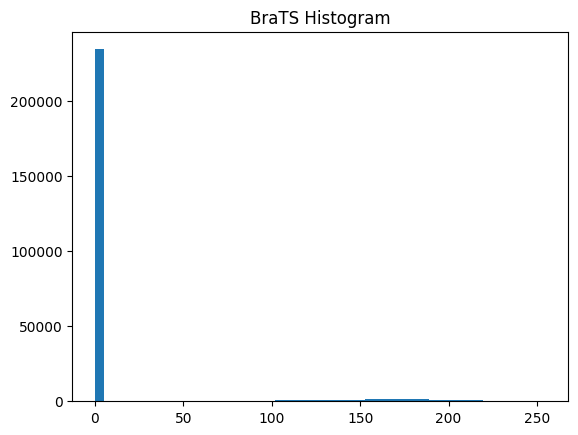

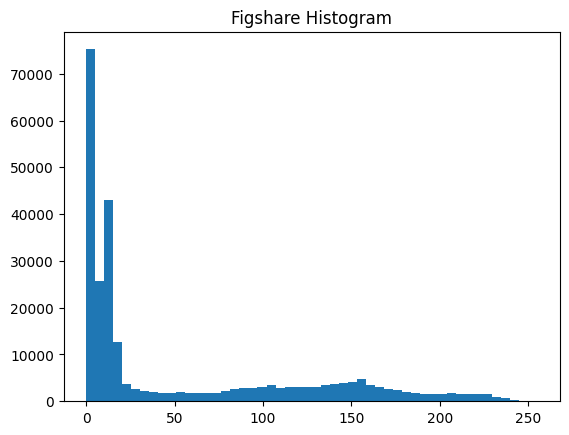

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram(folder, title):
    img = cv2.imread(os.path.join(folder, os.listdir(folder)[0]), 0)
    plt.hist(img.ravel(), bins=50)
    plt.title(title)
    plt.show()

plot_histogram("brats_yolo/images", "BraTS Histogram")
plot_histogram("figshare_yolo/images", "Figshare Histogram")

In [5]:
def check_label(folder):
    lbl = os.listdir(folder)[0]
    with open(os.path.join(folder, lbl)) as f:
        print("Sample label:", f.read())

print("BraTS label:")
check_label("brats_yolo/labels")

print("\nFigshare label:")
check_label("figshare_yolo/labels")

BraTS label:
Sample label: 0 0.451171875 0.392578125 0.0078125 0.0078125

Figshare label:
Sample label: 1 0.6318359375 0.4189453125 0.220703125 0.150390625


In [7]:
from collections import Counter
import os

def class_count(folder):
    counter = Counter()

    for file in os.listdir(folder):
        with open(os.path.join(folder, file), 'r') as f:
            first_char = f.read(1)
            counter[int(first_char)] += 1

    return counter

print("BraTS class distribution:", class_count("brats_yolo/labels"))
print("Figshare class distribution:", class_count("figshare_yolo/labels"))

BraTS class distribution: Counter({0: 24354})
Figshare class distribution: Counter({0: 1426, 2: 930, 1: 708})


BraTS sample:


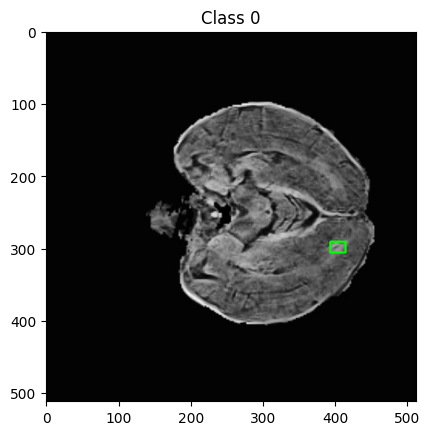

Figshare sample:


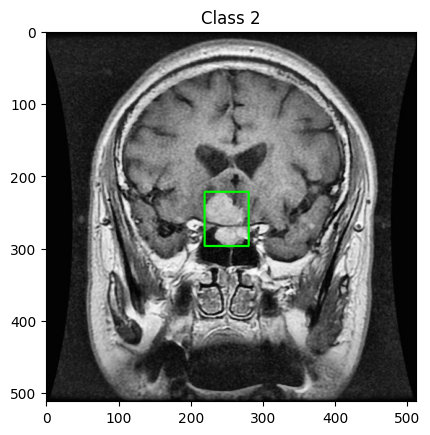

In [8]:
import random

def visualize_sample(img_folder, label_folder):
    img_name = random.choice(os.listdir(img_folder))
    img = cv2.imread(os.path.join(img_folder, img_name))
    h, w, _ = img.shape

    label_name = img_name.replace(".jpg", ".txt")
    with open(os.path.join(label_folder, label_name)) as f:
        cls, xc, yc, bw, bh = map(float, f.read().split())

    x = int((xc - bw/2) * w)
    y = int((yc - bh/2) * h)
    bw = int(bw * w)
    bh = int(bh * h)

    cv2.rectangle(img, (x,y), (x+bw, y+bh), (0,255,0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Class {int(cls)}")
    plt.show()

print("BraTS sample:")
visualize_sample("brats_yolo/images", "brats_yolo/labels")

print("Figshare sample:")
visualize_sample("figshare_yolo/images", "figshare_yolo/labels")

In [ ]:
import os
import shutil
import random
from collections import defaultdict

# =============================
# SETTINGS
# =============================

BRATS_DIR = "brats_yolo"
FIG_DIR = "figshare_yolo"
MERGED_DIR = "brain_merged_final"

BRATS_GLIOMA_COUNT = 1000
FIG_GLIOMA_COUNT = 700

random.seed(42)

os.makedirs(f"{MERGED_DIR}/images", exist_ok=True)
os.makedirs(f"{MERGED_DIR}/labels", exist_ok=True)

# =============================
# HELPER: GROUP FIGSHARE BY CLASS
# =============================

def group_by_class(label_dir):
    class_dict = defaultdict(list)
    for file in os.listdir(label_dir):
        with open(os.path.join(label_dir, file)) as f:
            cls = int(f.readline().split()[0])
        class_dict[cls].append(file.replace(".txt", ".jpg"))
    return class_dict

counter = 0

# =============================
# 1️⃣ SAMPLE BRATS (class 0)
# =============================

brats_images = os.listdir(f"{BRATS_DIR}/images")

if len(brats_images) < BRATS_GLIOMA_COUNT:
    raise Exception("Not enough BraTS images.")

brats_sample = random.sample(brats_images, BRATS_GLIOMA_COUNT)

for img in brats_sample:
    new_img = f"img_{counter}.jpg"
    new_lbl = f"img_{counter}.txt"

    shutil.copy(
        f"{BRATS_DIR}/images/{img}",
        f"{MERGED_DIR}/images/{new_img}"
    )
    shutil.copy(
        f"{BRATS_DIR}/labels/{img.replace('.jpg','.txt')}",
        f"{MERGED_DIR}/labels/{new_lbl}"
    )

    counter += 1

print("BraTS glioma copied:", BRATS_GLIOMA_COUNT)

# =============================
# 2️⃣ FIGSHARE PROCESSING
# =============================

fig_classes = group_by_class(f"{FIG_DIR}/labels")

# ---- Class 0 (glioma) sample ----
fig_glioma = fig_classes[0]

if len(fig_glioma) < FIG_GLIOMA_COUNT:
    raise Exception("Not enough Figshare glioma images.")

fig_glioma_sample = random.sample(fig_glioma, FIG_GLIOMA_COUNT)

# ---- Class 1 & 2 (take ALL) ----
fig_meningioma = fig_classes[1]
fig_pituitary = fig_classes[2]

# Combine all selected figshare
fig_selected = fig_glioma_sample + fig_meningioma + fig_pituitary

for img in fig_selected:
    new_img = f"img_{counter}.jpg"
    new_lbl = f"img_{counter}.txt"

    shutil.copy(
        f"{FIG_DIR}/images/{img}",
        f"{MERGED_DIR}/images/{new_img}"
    )
    shutil.copy(
        f"{FIG_DIR}/labels/{img.replace('.jpg','.txt')}",
        f"{MERGED_DIR}/labels/{new_lbl}"
    )

    counter += 1

print("Figshare merged.")
print("=================================")
print("Total merged samples:", counter)
print("=================================")

BraTS glioma copied: 1000
Figshare merged.
Total merged samples: 3338


In [ ]:
from collections import Counter
import os

def class_count(folder):
    counter = Counter()
    for file in os.listdir(folder):
        with open(os.path.join(folder, file)) as f:
            cls = int(f.readline().split()[0])
            counter[cls] += 1
    return counter

print(class_count("brain_merged_final/labels"))

Counter({0: 1700, 2: 930, 1: 708})


In [15]:
import os

IMG_DIR = "brain_merged_final/images"

for file in os.listdir(IMG_DIR):
    path = os.path.join(IMG_DIR, file)

    if os.path.isfile(path):   # only loose image files
        os.remove(path)

print("Loose images removed.")

Loose images removed.


In [16]:
import os

DATASET_DIR = "brain_merged_final"

IMG_DIR = os.path.join(DATASET_DIR, "images")
LBL_DIR = os.path.join(DATASET_DIR, "labels")

# Remove loose images
for file in os.listdir(IMG_DIR):
    path = os.path.join(IMG_DIR, file)
    if os.path.isfile(path):
        os.remove(path)

# Remove loose labels
for file in os.listdir(LBL_DIR):
    path = os.path.join(LBL_DIR, file)
    if os.path.isfile(path):
        os.remove(path)

print("Loose images and labels removed.")

Loose images and labels removed.


In [17]:
import os
from collections import Counter

DATASET_DIR = "brain_merged_final"

IMG_DIR = os.path.join(DATASET_DIR, "images")
LBL_DIR = os.path.join(DATASET_DIR, "labels")

VALID_CLASSES = {0, 1, 2}

def verify_split(split):

    print(f"\n===== Checking {split.upper()} =====")

    img_path = os.path.join(IMG_DIR, split)
    lbl_path = os.path.join(LBL_DIR, split)

    images = set(os.listdir(img_path))
    labels = set(os.listdir(lbl_path))

    # Remove non-files if any
    images = {f for f in images if f.endswith(".jpg")}
    labels = {f for f in labels if f.endswith(".txt")}

    # 1️⃣ Check missing labels
    missing_labels = []
    for img in images:
        if img.replace(".jpg", ".txt") not in labels:
            missing_labels.append(img)

    # 2️⃣ Check missing images
    missing_images = []
    for lbl in labels:
        if lbl.replace(".txt", ".jpg") not in images:
            missing_images.append(lbl)

    # 3️⃣ Validate label content
    invalid_boxes = []
    invalid_classes = []
    class_counter = Counter()

    for lbl in labels:
        with open(os.path.join(lbl_path, lbl)) as f:
            line = f.readline().strip().split()

            if len(line) != 5:
                invalid_boxes.append(lbl)
                continue

            cls = int(line[0])
            x, y, w, h = map(float, line[1:])

            class_counter[cls] += 1

            # Check class id
            if cls not in VALID_CLASSES:
                invalid_classes.append(lbl)

            # Check bounding box range
            if not (0 <= x <= 1 and 0 <= y <= 1 and
                    0 <= w <= 1 and 0 <= h <= 1):
                invalid_boxes.append(lbl)

    # Print results
    print("Total images:", len(images))
    print("Total labels:", len(labels))
    print("Class distribution:", dict(class_counter))

    if missing_labels:
        print("❌ Missing labels for images:", len(missing_labels))
    else:
        print("✅ No missing labels")

    if missing_images:
        print("❌ Missing images for labels:", len(missing_images))
    else:
        print("✅ No missing images")

    if invalid_boxes:
        print("❌ Invalid bounding boxes:", len(invalid_boxes))
    else:
        print("✅ All bounding boxes valid")

    if invalid_classes:
        print("❌ Invalid class IDs:", len(invalid_classes))
    else:
        print("✅ All class IDs valid")


# Run verification
verify_split("train")
verify_split("val")

print("\n===== VERIFICATION COMPLETE =====")


===== Checking TRAIN =====
Total images: 2670
Total labels: 2670
Class distribution: {2: 744, 0: 1360, 1: 566}
✅ No missing labels
✅ No missing images
✅ All bounding boxes valid
✅ All class IDs valid

===== Checking VAL =====
Total images: 668
Total labels: 668
Class distribution: {0: 340, 2: 186, 1: 142}
✅ No missing labels
✅ No missing images
✅ All bounding boxes valid
✅ All class IDs valid

===== VERIFICATION COMPLETE =====


In [ ]:

from ultralytics import YOLO

model = YOLO("yolo12n.pt")   # nano model

results = model.train(
    data="brain_merged_detect/data.yaml",
    imgsz=512,
    epochs=150,
    batch=4,
    optimizer="AdamW",
    lr0=0.001,
    device=0,          # use GPU (remove if CPU)
    workers=2,        # reduce workers for stability

    # -------- Light medical-safe augmentation --------
    hsv_h=0.02,
    hsv_s=0.2,
    hsv_v=0.2,
    scale=0.05,
    translate=0.03,
    mosaic=0.3,
    mixup=0.05,
    degrees=5,

    # -------- Training stability --------
    cos_lr=True,
    patience=30,
    label_smoothing=0.05,

       
    name="yolov12_merge",    # experiment name
    exist_ok=True    
)

WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.252  Python-3.10.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=brain_merged_final/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.2, hsv_v=0.2, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=0.3, multi_scale=False, name=yolov12_merge, nbs=64, nms=False, opset=None, 

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [1]:
import os
import shutil
import random
from collections import defaultdict

# =============================
# SETTINGS
# =============================

BRATS_DIR = "brats_yolo"
FIG_DIR = "figshare_yolo"
MERGED_DIR = "brain_merged_final_2"

BRATS_GLIOMA_COUNT = 1500
FIG_GLIOMA_COUNT = 1000

random.seed(42)

os.makedirs(f"{MERGED_DIR}/images", exist_ok=True)
os.makedirs(f"{MERGED_DIR}/labels", exist_ok=True)

# =============================
# HELPER: GROUP FIGSHARE BY CLASS
# =============================

def group_by_class(label_dir):
    class_dict = defaultdict(list)
    for file in os.listdir(label_dir):
        with open(os.path.join(label_dir, file)) as f:
            cls = int(f.readline().split()[0])
        class_dict[cls].append(file.replace(".txt", ".jpg"))
    return class_dict

counter = 0

# =============================
# 1️⃣ SAMPLE BRATS (class 0)
# =============================

brats_images = os.listdir(f"{BRATS_DIR}/images")

if len(brats_images) < BRATS_GLIOMA_COUNT:
    raise Exception("Not enough BraTS images.")

brats_sample = random.sample(brats_images, BRATS_GLIOMA_COUNT)

for img in brats_sample:
    new_img = f"img_{counter}.jpg"
    new_lbl = f"img_{counter}.txt"

    shutil.copy(
        f"{BRATS_DIR}/images/{img}",
        f"{MERGED_DIR}/images/{new_img}"
    )
    shutil.copy(
        f"{BRATS_DIR}/labels/{img.replace('.jpg','.txt')}",
        f"{MERGED_DIR}/labels/{new_lbl}"
    )

    counter += 1

print("BraTS glioma copied:", BRATS_GLIOMA_COUNT)

# =============================
# 2️⃣ FIGSHARE PROCESSING
# =============================

fig_classes = group_by_class(f"{FIG_DIR}/labels")

# ---- Class 0 (glioma) sample ----
fig_glioma = fig_classes[0]

if len(fig_glioma) < FIG_GLIOMA_COUNT:
    raise Exception("Not enough Figshare glioma images.")

fig_glioma_sample = random.sample(fig_glioma, FIG_GLIOMA_COUNT)

# ---- Class 1 & 2 (take ALL) ----
fig_meningioma = fig_classes[1]
fig_pituitary = fig_classes[2]

# Combine all selected figshare
fig_selected = fig_glioma_sample + fig_meningioma + fig_pituitary

for img in fig_selected:
    new_img = f"img_{counter}.jpg"
    new_lbl = f"img_{counter}.txt"

    shutil.copy(
        f"{FIG_DIR}/images/{img}",
        f"{MERGED_DIR}/images/{new_img}"
    )
    shutil.copy(
        f"{FIG_DIR}/labels/{img.replace('.jpg','.txt')}",
        f"{MERGED_DIR}/labels/{new_lbl}"
    )

    counter += 1

print("Figshare merged.")
print("=================================")
print("Total merged samples:", counter)
print("=================================")

BraTS glioma copied: 1500
Figshare merged.
Total merged samples: 4138


In [4]:
from collections import Counter
import os

def class_count(folder):
    counter = Counter()
    for file in os.listdir(folder):
        with open(os.path.join(folder, file)) as f:
            cls = int(f.readline().split()[0])
            counter[cls] += 1
    return counter

print(class_count("brain_merged_final_2/labels"))

Counter({0: 2500, 2: 930, 1: 708})


In [5]:
import os
import shutil
import random
from collections import defaultdict, Counter

# ============================
# SETTINGS
# ============================

DATASET_DIR = "brain_merged_final_2"
TRAIN_RATIO = 0.8
random.seed(42)

IMG_DIR = os.path.join(DATASET_DIR, "images")
LBL_DIR = os.path.join(DATASET_DIR, "labels")

# ============================
# Create train/val folders
# ============================

for split in ["train", "val"]:
    os.makedirs(os.path.join(IMG_DIR, split), exist_ok=True)
    os.makedirs(os.path.join(LBL_DIR, split), exist_ok=True)

# ============================
# Group images by class
# ============================

class_dict = defaultdict(list)

for file in os.listdir(LBL_DIR):

    # Skip directories
    if not file.endswith(".txt"):
        continue

    label_path = os.path.join(LBL_DIR, file)

    with open(label_path) as f:
        cls = int(f.readline().split()[0])

    img_name = file.replace(".txt", ".jpg")
    class_dict[cls].append(img_name)

# ============================
# Stratified split
# ============================

for cls, images in class_dict.items():

    random.shuffle(images)
    split_index = int(len(images) * TRAIN_RATIO)

    train_imgs = images[:split_index]
    val_imgs = images[split_index:]

    # ---- TRAIN ----
    for img in train_imgs:
        shutil.copy(
            os.path.join(IMG_DIR, img),
            os.path.join(IMG_DIR, "train", img)
        )
        shutil.copy(
            os.path.join(LBL_DIR, img.replace(".jpg", ".txt")),
            os.path.join(LBL_DIR, "train", img.replace(".jpg", ".txt"))
        )

    # ---- VAL ----
    for img in val_imgs:
        shutil.copy(
            os.path.join(IMG_DIR, img),
            os.path.join(IMG_DIR, "val", img)
        )
        shutil.copy(
            os.path.join(LBL_DIR, img.replace(".jpg", ".txt")),
            os.path.join(LBL_DIR, "val", img.replace(".jpg", ".txt"))
        )

print("================================")
print("Stratified split completed.")
print("================================")

# ============================
# Verify distribution
# ============================

def count_classes(folder):
    counter = Counter()
    for file in os.listdir(folder):
        if not file.endswith(".txt"):
            continue
        with open(os.path.join(folder, file)) as f:
            cls = int(f.readline().split()[0])
            counter[cls] += 1
    return counter

print("Train distribution:",
      count_classes(os.path.join(LBL_DIR, "train")))

print("Val distribution:",
      count_classes(os.path.join(LBL_DIR, "val")))

Stratified split completed.
Train distribution: Counter({0: 2000, 2: 744, 1: 566})
Val distribution: Counter({0: 500, 2: 186, 1: 142})


In [8]:
import os

DATASET_DIR = "brain_merged_final_2"

IMG_DIR = os.path.join(DATASET_DIR, "images")
LBL_DIR = os.path.join(DATASET_DIR, "labels")

# Remove loose images
for file in os.listdir(IMG_DIR):
    path = os.path.join(IMG_DIR, file)
    if os.path.isfile(path):
        os.remove(path)

# Remove loose labels
for file in os.listdir(LBL_DIR):
    path = os.path.join(LBL_DIR, file)
    if os.path.isfile(path):
        os.remove(path)

print("Loose images and labels removed.")

Loose images and labels removed.


In [7]:
import os
from collections import Counter

DATASET_DIR = "brain_merged_final"

IMG_DIR = os.path.join(DATASET_DIR, "images")
LBL_DIR = os.path.join(DATASET_DIR, "labels")

VALID_CLASSES = {0, 1, 2}

def verify_split(split):

    print(f"\n===== Checking {split.upper()} =====")

    img_path = os.path.join(IMG_DIR, split)
    lbl_path = os.path.join(LBL_DIR, split)

    images = set(os.listdir(img_path))
    labels = set(os.listdir(lbl_path))

    # Remove non-files if any
    images = {f for f in images if f.endswith(".jpg")}
    labels = {f for f in labels if f.endswith(".txt")}

    # 1️⃣ Check missing labels
    missing_labels = []
    for img in images:
        if img.replace(".jpg", ".txt") not in labels:
            missing_labels.append(img)

    # 2️⃣ Check missing images
    missing_images = []
    for lbl in labels:
        if lbl.replace(".txt", ".jpg") not in images:
            missing_images.append(lbl)

    # 3️⃣ Validate label content
    invalid_boxes = []
    invalid_classes = []
    class_counter = Counter()

    for lbl in labels:
        with open(os.path.join(lbl_path, lbl)) as f:
            line = f.readline().strip().split()

            if len(line) != 5:
                invalid_boxes.append(lbl)
                continue

            cls = int(line[0])
            x, y, w, h = map(float, line[1:])

            class_counter[cls] += 1

            # Check class id
            if cls not in VALID_CLASSES:
                invalid_classes.append(lbl)

            # Check bounding box range
            if not (0 <= x <= 1 and 0 <= y <= 1 and
                    0 <= w <= 1 and 0 <= h <= 1):
                invalid_boxes.append(lbl)

    # Print results
    print("Total images:", len(images))
    print("Total labels:", len(labels))
    print("Class distribution:", dict(class_counter))

    if missing_labels:
        print("❌ Missing labels for images:", len(missing_labels))
    else:
        print("✅ No missing labels")

    if missing_images:
        print("❌ Missing images for labels:", len(missing_images))
    else:
        print("✅ No missing images")

    if invalid_boxes:
        print("❌ Invalid bounding boxes:", len(invalid_boxes))
    else:
        print("✅ All bounding boxes valid")

    if invalid_classes:
        print("❌ Invalid class IDs:", len(invalid_classes))
    else:
        print("✅ All class IDs valid")


# Run verification
verify_split("train")
verify_split("val")

print("\n===== VERIFICATION COMPLETE =====")


===== Checking TRAIN =====
Total images: 2670
Total labels: 2670
Class distribution: {0: 1360, 2: 744, 1: 566}
✅ No missing labels
✅ No missing images
✅ All bounding boxes valid
✅ All class IDs valid

===== Checking VAL =====
Total images: 668
Total labels: 668
Class distribution: {0: 340, 2: 186, 1: 142}
✅ No missing labels
✅ No missing images
✅ All bounding boxes valid
✅ All class IDs valid

===== VERIFICATION COMPLETE =====


In [1]:

from ultralytics import YOLO

# -------------------------------
# Load lightweight model
# -------------------------------
model = YOLO("yolo12n.pt")

# -------------------------------
# Safe Training Config
# -------------------------------
model.train(
    
    # Dataset
    data="brain_merged_final_2/data1.yaml",
    
    # Image size (safe for GPU + CPU)
    imgsz=640,
    
    # Batch size (stable)
    batch=4,                 # increase to 6 only if GPU allows
    
    # Training duration
    epochs=150,              # safe length
    patience=50,
    
    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    
    # Device
    device=0,                # GPU
    workers=2,               # VERY IMPORTANT (safe for Windows)
    
    # -------- Light Medical Augmentation --------
    hsv_h=0.01,
    hsv_s=0.1,
    hsv_v=0.1,
    scale=0.05,
    translate=0.03,
    degrees=3,
    freeze=6,

    # Reduce heavy mixing (prevents CPU stress)
    mosaic=0.3,
    mixup=0.0,
    
    # Stability
    cos_lr=True,
    label_smoothing=0.02,
    
    # AMP (automatic mixed precision)
    amp=True,
    
    # Save settings
    project="runs/detect",
    name="yolov12n_safe_training",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.18 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.252  Python-3.10.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=brain_merged_final_2/data1.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=6, half=False, hsv_h=0.01, hsv_s=0.1, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001E83A15A920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [ ]:


from ultralytics import YOLO
import os

# ====== CHANGE THIS PATH ONLY ======
AUGMENTED_MODEL = r"C:\Users\abhis\Documents\yolo_merge\runs\detect\runs\detect\yolov12n_safe_training\weights\best.pt"
DATA_YAML = r"C:\Users\abhis\Documents\yolo_merge\brain_merged_final_2\data1.yaml"

# Safety checks
if not os.path.exists(AUGMENTED_MODEL):
    raise FileNotFoundError(f"Model not found: {AUGMENTED_MODEL}")
if not os.path.exists(DATA_YAML):
    raise FileNotFoundError(f"data.yaml not found: {DATA_YAML}")

# Load and validate
model = YOLO(AUGMENTED_MODEL)
metrics = model.val(data=DATA_YAML, verbose=False)

names = metrics.names

print("\n===== OVERALL METRICS (AUGMENTED MODEL) =====")
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")

print("\n===== PER-CLASS METRICS (AUGMENTED MODEL) =====")

for i, name in names.items():
    print(f"\nClass {i}: {name}")
    print(f"  Precision     : {metrics.box.p[i]:.4f}")
    print(f"  Recall        : {metrics.box.r[i]:.4f}")
    print(f"  mAP@0.5       : {metrics.box.ap50[i]:.4f}")
    print(f"  mAP@0.5:0.95  : {metrics.box.ap[i]:.4f}")

print("\n===== EVALUATION COMPLETE =====")


In [4]:
!pip install grad-cam

  Using cached grad-cam-1.5.5.tar.gz (7.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44340 sha256=6f9fc15263edf186feaa236dc2a1a73e3267e7923189bd525b5931e34a3ea6f1
  Stored in directory: c:\users\abhis\appdata\local\pip\cache\wheels\3d\b6\be\e13ccc


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.8 MB 4.2 MB/s eta 0:00:02
     ------ --------------------------------- 1.3/7.8 MB 4.2 MB/s eta 0:00:02
     --------- ------------------------------ 1.8/7.8 MB 3.7 MB/s eta 0:00:02
     ------------- -------------------------- 2.6/7.8 MB 3.5 MB/s eta 0:00:02
     ---------------- ----------------------- 3.1/7.8 MB 3.5 MB/s eta 0:00:02
     ------------------ --------------------- 3.7/7.8 MB 3.3 MB/s eta 0:00:02
     --------------------- ------------------ 4.2/7.8 MB 3.2 MB/s eta 0:00:02
     ------------------------- -------------- 5.0/7.8 MB 3.1 MB/s eta 0:00:01
     ---------------------------- ----------- 5.5/7.8 MB 3.1 MB/s eta 0:00:01
     ------------------------------ --------- 6.0/7.8 MB 3.1 MB/s eta 0:00:01
     ----------------------------------- ---- 6.8/7.8 MB 3.2 MB/s eta 0:00:01
     ------------------------------------- -- 7.3/7.8 MB 3.1 MB/s eta 0

In [21]:
import torch
import cv2
import numpy as np
from ultralytics import YOLO

# Load model
model = YOLO(r"C:\Users\abhis\Documents\yolo_merge\runs\detect\yolov12_merge\weights\best.pt")
net = model.model
net.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)

for param in net.parameters():
    param.requires_grad = True

# 🔥 Use layer before Detect
target_layer = net.model[-2]
print("Using:", target_layer)

activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def generate_gradcam(image_path):

    activations.clear()
    gradients.clear()

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (640, 640))
    img_float = img_resized.astype(np.float32) / 255.0

    input_tensor = torch.from_numpy(img_float).permute(2, 0, 1).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    output = net(input_tensor)

    loss = output[0][..., 4].sum()  # objectness

    net.zero_grad()
    loss.backward()

    act = activations[0].detach().cpu().numpy()[0]
    grad = gradients[0].detach().cpu().numpy()[0]

    weights = np.mean(grad, axis=(1, 2))

    cam = np.zeros(act.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (640, 640))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    result = heatmap * 0.4 + img_resized

    cv2.imwrite("gradcam_result.jpg", result.astype(np.uint8))
    print("Saved: gradcam_result.jpg")

generate_gradcam(
    r"C:\Users\abhis\Documents\yolo_merge\merged_dataset\test\images\3.png"
)

Using: C3k2(
  (cv1): Conv(
    (conv): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): C3k(
      (cv1): Conv(
        (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv3): Conv(
        (conv): Conv2d(128, 128

In [24]:
import cv2
import numpy as np
from ultralytics import YOLO

# -------------------------
# Load model
# -------------------------
model = YOLO(r"C:\Users\abhis\Documents\yolo_merge\runs\segment\runs\detect\yolov12n_safe_training\weights\best.pt")   # put correct path

# -------------------------
# Occlusion Sensitivity
# -------------------------
def occlusion_map(image_path, patch_size=40, stride=20):

    img = cv2.imread(image_path)
    h, w, _ = img.shape

    base_result = model(image_path)[0]

    if len(base_result.boxes) == 0:
        print("No detection.")
        return

    base_conf = float(base_result.boxes.conf[0])
    print("Original confidence:", base_conf)

    heatmap = np.zeros((h, w))

    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):

            occluded = img.copy()
            occluded[y:y+patch_size, x:x+patch_size] = 0

            result = model(occluded)[0]

            if len(result.boxes) == 0:
                conf = 0
            else:
                conf = float(result.boxes.conf[0])

            drop = base_conf - conf
            heatmap[y:y+patch_size, x:x+patch_size] += drop

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
    overlay = heatmap_color * 0.4 + img

    cv2.imwrite("occlusion_map.jpg", overlay.astype(np.uint8))
    print("Saved occlusion_map.jpg")


# -------------------------
# Run
# -------------------------
occlusion_map(
    r"C:\Users\abhis\Documents\yolo_merge\merged_dataset\test\images\3.png"
)


image 1/1 C:\Users\abhis\Documents\yolo_merge\merged_dataset\test\images\3.png: 640x640 1 meningioma, 11.9ms
Speed: 3.3ms preprocess, 11.9ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 640)
Original confidence: 0.8655208349227905

0: 640x640 1 meningioma, 13.6ms
Speed: 3.4ms preprocess, 13.6ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 meningioma, 11.7ms
Speed: 3.1ms preprocess, 11.7ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 meningioma, 10.8ms
Speed: 2.8ms preprocess, 10.8ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 meningioma, 14.3ms
Speed: 3.1ms preprocess, 14.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 meningioma, 11.1ms
Speed: 2.7ms preprocess, 11.1ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 meningioma, 10.5ms
Speed: 3.0ms preprocess, 10.5ms inference, 2.7ms postprocess per image

In [5]:
import os
import cv2
import numpy as np
import nibabel as nib
from tqdm import tqdm

# =====================================
# PATH (MATCHES YOUR STRUCTURE)
# =====================================

BRATS_ROOT = r"C:\Users\abhis\Documents\yolo_merge\brats20-dataset-training-validation\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData"

OUTPUT_IMG = "processed_brats/images"
OUTPUT_LABEL = "processed_brats/labels"

IMG_SIZE = 512

os.makedirs(OUTPUT_IMG, exist_ok=True)
os.makedirs(OUTPUT_LABEL, exist_ok=True)

# =====================================
# PREPROCESSING FUNCTIONS (Paper Style)
# =====================================

def log_transform(img):
    img = img.astype(np.float32)
    c = 255 / np.log(1 + np.max(img))
    return c * np.log(1 + img)

def hist_equalization(img):
    img = img.astype(np.uint8)
    return cv2.equalizeHist(img)

def refine_mask(mask):
    kernel = np.ones((3,3), np.uint8)
    return cv2.dilate(mask, kernel, iterations=2)

def mask_to_polygons(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for cnt in contours:
        if len(cnt) < 6:
            continue
        cnt = cnt.squeeze()
        if len(cnt.shape) != 2:
            continue
        cnt = cnt / IMG_SIZE
        polygons.append(cnt.flatten().tolist())
    return polygons

# =====================================
# MAIN LOOP
# =====================================

patients = os.listdir(BRATS_ROOT)
counter = 0

for patient in tqdm(patients):

    patient_path = os.path.join(BRATS_ROOT, patient)

    flair_path = os.path.join(patient_path, f"{patient}_flair.nii")
    seg_path = os.path.join(patient_path, f"{patient}_seg.nii")

    if not os.path.exists(flair_path) or not os.path.exists(seg_path):
        continue

    flair = nib.load(flair_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()

    for i in range(seg.shape[2]):

        mask = seg[:, :, i]

        if np.sum(mask) == 0:
            continue

        img = flair[:, :, i]

        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        # ===== Paper preprocessing =====
        img = log_transform(img)
        img = hist_equalization(img)
        img = img / 255.0

        mask = (mask > 0).astype(np.uint8) * 255
        mask = refine_mask(mask)

        polygons = mask_to_polygons(mask)

        if len(polygons) == 0:
            continue

        img_name = f"{patient}_{i}.png"

        cv2.imwrite(
            os.path.join(OUTPUT_IMG, img_name),
            (img * 255).astype(np.uint8)
        )

        with open(os.path.join(OUTPUT_LABEL, img_name.replace(".png", ".txt")), "w") as f:
            for poly in polygons:
                f.write("0 " + " ".join(map(str, poly)) + "\n")

        counter += 1

print("Finished preprocessing")
print("Total slices saved:", counter)

 92%|█████████▏| 340/371 [03:50<00:21,  1.46it/s]C:\Users\abhis\AppData\Local\Temp\ipykernel_25776\2318288011.py:28: RuntimeWarning: invalid value encountered in log
  return c * np.log(1 + img)
C:\Users\abhis\AppData\Local\Temp\ipykernel_25776\2318288011.py:31: RuntimeWarning: invalid value encountered in cast
  img = img.astype(np.uint8)
100%|██████████| 371/371 [04:10<00:00,  1.48it/s]

Finished preprocessing
Total slices saved: 24066


In [6]:
import h5py

FIG_ROOT = r"C:\Users\abhis\Documents\yolo_merge\figshare-brain-tumor-dataset\dataset\data"
OUTPUT_IMG = "processed/figshare/images"
OUTPUT_LABEL = "processed/figshare/labels"

os.makedirs(OUTPUT_IMG, exist_ok=True)
os.makedirs(OUTPUT_LABEL, exist_ok=True)

for file in tqdm(os.listdir(FIG_ROOT)):
    if not file.endswith(".mat"):
        continue
        
    path = os.path.join(FIG_ROOT, file)
    with h5py.File(path, 'r') as f:
        img = np.array(f['cjdata']['image']).T
        mask = np.array(f['cjdata']['tumorMask']).T
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    
    img = log_transform(img)
    img = hist_equalization(img)
    img = img / 255.0
    
    mask = (mask > 0).astype(np.uint8)*255
    mask = refine_mask(mask)
    
    polygons = mask_to_polygon(mask)
    
    img_name = file.replace(".mat",".png")
    cv2.imwrite(os.path.join(OUTPUT_IMG, img_name), img*255)
    
    with open(os.path.join(OUTPUT_LABEL, img_name.replace(".png",".txt")), "w") as f:
        for poly in polygons:
            f.write("0 " + " ".join(map(str, poly)) + "\n")

100%|██████████| 3064/3064 [01:08<00:00, 44.73it/s]


In [20]:
import os
import cv2
import numpy as np
import h5py
from tqdm import tqdm
import time

# =====================================
# PATHS
# =====================================

FIG_ROOT = r"C:\Users\abhis\Documents\yolo_merge\figshare-brain-tumor-dataset\dataset\data"
OUTPUT_IMG = "processed/figshare/images"
OUTPUT_LABEL = "processed/figshare/labels"

IMG_SIZE = 512

os.makedirs(OUTPUT_IMG, exist_ok=True)
os.makedirs(OUTPUT_LABEL, exist_ok=True)

# =====================================
# PREPROCESSING FUNCTIONS
# =====================================

def log_transform(img):
    img = img.astype(np.float32)
    max_val = np.max(img)
    if max_val == 0:
        return img
    c = 255 / np.log(1 + max_val)
    return c * np.log(1 + img)

def hist_equalization(img):
    img = img.astype(np.uint8)
    return cv2.equalizeHist(img)

def refine_mask(mask):
    kernel = np.ones((3, 3), np.uint8)
    return cv2.dilate(mask, kernel, iterations=2)

def mask_to_polygons(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []

    for cnt in contours:
        if len(cnt) < 6:
            continue

        cnt = cnt.squeeze()

        if len(cnt.shape) != 2:
            continue

        cnt = cnt / IMG_SIZE  # normalize for YOLO
        polygons.append(cnt.flatten().tolist())

    return polygons

# =====================================
# CLASS MAPPING
# =====================================

# Original dataset labels:
# 1 = meningioma
# 2 = glioma
# 3 = pituitary

label_mapping = {
    1: 1,  # meningioma
    2: 0,  # glioma
    3: 2   # pituitary
}

class_counter = {0: 0, 1: 0, 2: 0}

# =====================================
# TIMER START
# =====================================

start_time = time.time()

# =====================================
# MAIN PROCESSING LOOP
# =====================================

for file in tqdm(os.listdir(FIG_ROOT), desc="Processing Figshare"):

    if not file.endswith(".mat"):
        continue

    path = os.path.join(FIG_ROOT, file)

    try:
        with h5py.File(path, 'r') as f:
            img = np.array(f['cjdata']['image']).T
            mask = np.array(f['cjdata']['tumorMask']).T
            raw_label = int(np.array(f['cjdata']['label'])[0][0])
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

    if raw_label not in label_mapping:
        continue

    class_id = label_mapping[raw_label]

    # Skip empty masks
    if np.sum(mask) == 0:
        continue

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    # Image preprocessing
    img = log_transform(img)
    img = hist_equalization(img)
    img = img / 255.0

    # Mask processing
    mask = (mask > 0).astype(np.uint8) * 255
    mask = refine_mask(mask)

    polygons = mask_to_polygons(mask)

    if len(polygons) == 0:
        continue

    img_name = file.replace(".mat", ".png")

    # Save image
    cv2.imwrite(
        os.path.join(OUTPUT_IMG, img_name),
        (img * 255).astype(np.uint8)
    )

    # Save YOLO label
    with open(os.path.join(OUTPUT_LABEL, img_name.replace(".png", ".txt")), "w") as f:
        for poly in polygons:
            f.write(str(class_id) + " " + " ".join(map(str, poly)) + "\n")

    class_counter[class_id] += 1

# =====================================
# TIMER END
# =====================================

end_time = time.time()

print("\n==============================")
print("✅ FIGSHARE PROCESSING COMPLETE")
print("==============================")
print(f"Glioma (Class 0): {class_counter[0]}")
print(f"Meningioma (Class 1): {class_counter[1]}")
print(f"Pituitary (Class 2): {class_counter[2]}")
print(f"Total saved: {sum(class_counter.values())}")
print(f"Time taken: {end_time - start_time:.2f} seconds")
print("==============================")

Processing Figshare: 100%|██████████| 3064/3064 [01:10<00:00, 43.19it/s]


✅ FIGSHARE PROCESSING COMPLETE
Glioma (Class 0): 1426
Meningioma (Class 1): 708
Pituitary (Class 2): 930
Total saved: 3064
Time taken: 70.96 seconds


In [21]:
import os
import random
import shutil
import time
from tqdm import tqdm
import yaml

# ==============================
# PATHS (EDIT IF NEEDED)
# ==============================

BRATS_IMG = "processed_brats/images"
BRATS_LABEL = "processed_brats/labels"

FIG_IMG = "processed/figshare/images"
FIG_LABEL = "processed/figshare/labels"

MERGED_ROOT = "merged_dataset"
MERGED_IMG = os.path.join(MERGED_ROOT, "images")
MERGED_LABEL = os.path.join(MERGED_ROOT, "labels")

os.makedirs(MERGED_IMG, exist_ok=True)
os.makedirs(MERGED_LABEL, exist_ok=True)

# ==============================
# SETTINGS
# ==============================

BRATS_SAMPLE = 1500
FIG_CLASS0_SAMPLE = 1000

# ==============================
# TIMER START
# ==============================

start_time = time.time()

# ==============================
# HELPER FUNCTION
# ==============================

def copy_sample(img_name, src_img, src_label, new_class=None):
    """
    Copy image and label to merged dataset.
    Optionally override class id.
    """
    shutil.copy(os.path.join(src_img, img_name),
                os.path.join(MERGED_IMG, img_name))

    label_path = os.path.join(src_label, img_name.replace(".png", ".txt"))

    with open(label_path, "r") as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if new_class is not None:
            parts[0] = str(new_class)
        new_lines.append(" ".join(parts))

    with open(os.path.join(MERGED_LABEL, img_name.replace(".png", ".txt")), "w") as f:
        f.write("\n".join(new_lines))


# ==============================
# 1️⃣ BRAts (CLASS 0)
# ==============================

brats_images = os.listdir(BRATS_IMG)
brats_images = random.sample(brats_images, min(BRATS_SAMPLE, len(brats_images)))

print(f"Selected {len(brats_images)} BraTS samples")

for img in tqdm(brats_images, desc="Merging BraTS"):
    copy_sample(img, BRATS_IMG, BRATS_LABEL, new_class=0)

# ==============================
# 2️⃣ FIGSHARE DATA
# ==============================

fig_images = os.listdir(FIG_IMG)

fig_class0 = []
fig_class1 = []
fig_class2 = []

for img in fig_images:
    label_path = os.path.join(FIG_LABEL, img.replace(".png", ".txt"))

    if not os.path.exists(label_path):
        continue

    with open(label_path, "r") as f:
        first_line = f.readline().strip()
        if len(first_line) == 0:
            continue
        class_id = int(first_line.split()[0])

    if class_id == 0:
        fig_class0.append(img)
    elif class_id == 1:
        fig_class1.append(img)
    elif class_id == 2:
        fig_class2.append(img)

# Random sample class 0
fig_class0 = random.sample(fig_class0, min(FIG_CLASS0_SAMPLE, len(fig_class0)))

print(f"Selected {len(fig_class0)} Figshare class 0 samples")
print(f"Including ALL class 1: {len(fig_class1)}")
print(f"Including ALL class 2: {len(fig_class2)}")

# Merge them
for img in tqdm(fig_class0, desc="Merging Figshare Class 0"):
    copy_sample(img, FIG_IMG, FIG_LABEL)

for img in tqdm(fig_class1, desc="Merging Figshare Class 1"):
    copy_sample(img, FIG_IMG, FIG_LABEL)

for img in tqdm(fig_class2, desc="Merging Figshare Class 2"):
    copy_sample(img, FIG_IMG, FIG_LABEL)

# ==============================
# CREATE DATA.YAML
# ==============================

data_yaml = {
    "path": os.path.abspath(MERGED_ROOT),
    "train": "images",
    "val": "images",
    "nc": 3,
    "names": ["class0", "class1", "class2"]
}

with open(os.path.join(MERGED_ROOT, "data.yaml"), "w") as f:
    yaml.dump(data_yaml, f)

# ==============================
# TIMER END
# ==============================

end_time = time.time()
total_time = end_time - start_time

print("\n==============================")
print("✅ MERGING COMPLETE")
print("==============================")
print(f"Total images merged: {len(os.listdir(MERGED_IMG))}")
print(f"Time taken: {total_time:.2f} seconds")
print("==============================")

Selected 1500 BraTS samples


Merging BraTS: 100%|██████████| 1500/1500 [00:21<00:00, 68.67it/s]


Selected 1000 Figshare class 0 samples
Including ALL class 1: 708
Including ALL class 2: 930


Merging Figshare Class 2: 100%|██████████| 930/930 [00:07<00:00, 126.16it/s]


✅ MERGING COMPLETE
Total images merged: 6858
Time taken: 62.67 seconds


In [22]:
import os
import random
import shutil
import time
import yaml
from tqdm import tqdm

# =====================================
# PATHS
# =====================================

DATASET_ROOT = "merged_dataset"

IMG_PATH = os.path.join(DATASET_ROOT, "images")
LABEL_PATH = os.path.join(DATASET_ROOT, "labels")

TRAIN_IMG = os.path.join(DATASET_ROOT, "train/images")
TRAIN_LABEL = os.path.join(DATASET_ROOT, "train/labels")

TEST_IMG = os.path.join(DATASET_ROOT, "test/images")
TEST_LABEL = os.path.join(DATASET_ROOT, "test/labels")

# =====================================
# SETTINGS
# =====================================

SPLIT_RATIO = 0.8  # 80% train, 20% test
random.seed(42)

# =====================================
# CREATE FOLDERS
# =====================================

for path in [TRAIN_IMG, TRAIN_LABEL, TEST_IMG, TEST_LABEL]:
    os.makedirs(path, exist_ok=True)

# =====================================
# TIMER START
# =====================================

start_time = time.time()

# =====================================
# GET IMAGE LIST
# =====================================

images = [f for f in os.listdir(IMG_PATH) if f.endswith(".png")]
random.shuffle(images)

split_index = int(len(images) * SPLIT_RATIO)

train_files = images[:split_index]
test_files = images[split_index:]

print(f"Total images: {len(images)}")
print(f"Train images: {len(train_files)}")
print(f"Test images: {len(test_files)}")

# =====================================
# COPY FUNCTION
# =====================================

def copy_files(file_list, dest_img, dest_label):
    for img_name in tqdm(file_list):
        label_name = img_name.replace(".png", ".txt")

        shutil.copy(
            os.path.join(IMG_PATH, img_name),
            os.path.join(dest_img, img_name)
        )

        if os.path.exists(os.path.join(LABEL_PATH, label_name)):
            shutil.copy(
                os.path.join(LABEL_PATH, label_name),
                os.path.join(dest_label, label_name)
            )

# =====================================
# SPLIT COPYING
# =====================================

print("\nCopying Train Data...")
copy_files(train_files, TRAIN_IMG, TRAIN_LABEL)

print("\nCopying Test Data...")
copy_files(test_files, TEST_IMG, TEST_LABEL)

# =====================================
# CREATE DATA.YAML
# =====================================

data_yaml = {
    "path": os.path.abspath(DATASET_ROOT),
    "train": "train/images",
    "val": "test/images",
    "nc": 3,
    "names": {
        0: "glioma",
        1: "meningioma",
        2: "pituitary"
    }
}

with open(os.path.join(DATASET_ROOT, "data.yaml"), "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

# =====================================
# TIMER END
# =====================================

end_time = time.time()

print("\n==============================")
print("✅ SPLITTING COMPLETE")
print("==============================")
print(f"Time taken: {end_time - start_time:.2f} seconds")
print("data.yaml created successfully")
print("==============================")

Total images: 6858
Train images: 5486
Test images: 1372

Copying Train Data...


100%|██████████| 5486/5486 [01:03<00:00, 85.93it/s] 



Copying Test Data...


100%|██████████| 1372/1372 [00:15<00:00, 86.27it/s] 


✅ SPLITTING COMPLETE
Time taken: 79.76 seconds
data.yaml created successfully


In [23]:
import os
import hashlib
import time
from tqdm import tqdm

# =====================================
# DATASET ROOT
# =====================================

DATASET_ROOT = "merged_dataset"

SUBSETS = ["train", "test"]

# =====================================
# TIMER START
# =====================================

start_time = time.time()

def get_image_hash(image_path):
    """
    Compute MD5 hash of image file
    """
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

total_removed = 0

# =====================================
# CHECK EACH SUBSET
# =====================================

for subset in SUBSETS:

    print(f"\nChecking duplicates in {subset}...")

    image_folder = os.path.join(DATASET_ROOT, subset, "images")
    label_folder = os.path.join(DATASET_ROOT, subset, "labels")

    hashes = {}
    removed_count = 0

    for img_name in tqdm(os.listdir(image_folder)):

        if not img_name.endswith(".png"):
            continue

        img_path = os.path.join(image_folder, img_name)
        img_hash = get_image_hash(img_path)

        if img_hash in hashes:
            # Duplicate found → remove image + label
            os.remove(img_path)

            label_path = os.path.join(label_folder, img_name.replace(".png", ".txt"))
            if os.path.exists(label_path):
                os.remove(label_path)

            removed_count += 1
        else:
            hashes[img_hash] = img_name

    print(f"Removed {removed_count} duplicates from {subset}")
    total_removed += removed_count

# =====================================
# TIMER END
# =====================================

end_time = time.time()

print("\n==============================")
print("✅ DUPLICATE REMOVAL COMPLETE")
print("==============================")
print(f"Total duplicates removed: {total_removed}")
print(f"Time taken: {end_time - start_time:.2f} seconds")
print("==============================")


Checking duplicates in train...


100%|██████████| 5486/5486 [00:26<00:00, 206.10it/s]


Removed 0 duplicates from train

Checking duplicates in test...


100%|██████████| 1372/1372 [00:05<00:00, 240.29it/s]

Removed 0 duplicates from test

✅ DUPLICATE REMOVAL COMPLETE
Total duplicates removed: 0
Time taken: 32.34 seconds


In [3]:
import os

base = r"C:\Users\abhis\Documents\yolo_merge"

print("Folders inside yolo_merge:\n")
for item in os.listdir(base):
    print(item)

Folders inside yolo_merge:

brain_merged_final
brain_merged_final_2
brats20-dataset-training-validation
brats20-dataset-training-validation.zip
brats_yolo
figshare-brain-tumor-dataset
figshare-brain-tumor-dataset.zip
figshare_yolo
processed
processed_brats
runs
yolo11n.pt
yolo12n.pt
yolo_brats.ipynb


In [24]:

from ultralytics import YOLO

# -------------------------------
# Load lightweight model
# -------------------------------
model = YOLO("yolo11n-seg.pt")

# -------------------------------
# Safe Training Config
# -------------------------------
model.train(
    
    # Dataset
    data="merged_dataset/data.yaml",
    
    # Image size (safe for GPU + CPU)
    imgsz=640,
    
    # Batch size (stable)
    batch=4,                 # increase to 6 only if GPU allows
    
    # Training duration
    epochs=150,              # safe length
    patience=50,
    
    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    
    # Device
    device=0,                # GPU
    workers=2,               # VERY IMPORTANT (safe for Windows)
    
    # -------- Light Medical Augmentation --------
    hsv_h=0.01,
    hsv_s=0.1,
    hsv_v=0.1,
    scale=0.05,
    translate=0.03,
    degrees=3,
    freeze=6,

    # Reduce heavy mixing (prevents CPU stress)
    mosaic=0.3,
    mixup=0.0,
    
    # Stability
    cos_lr=True,
    label_smoothing=0.02,
    
    # AMP (automatic mixed precision)
    amp=True,
    
    # Save settings
    project="runs/detect",
    name="yolov12n_safe_training",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.252  Python-3.10.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=merged_dataset/data.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=6, half=False, hsv_h=0.01, hsv_s=0.1, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, mo

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020B1757B970>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    

YOLO12 BEFORE AUGMENTATION RESULTS


In [1]:


from ultralytics import YOLO
import os

# ====== CHANGE THIS PATH ONLY ======
AUGMENTED_MODEL = r"C:\Users\abhis\Documents\yolo_merge\runs\detect\runs\detect\yolov12n_safe_training\weights\best.pt"
DATA_YAML = r"C:\Users\abhis\Documents\yolo_merge\brain_merged_final_2\data1.yaml"

# Safety checks
if not os.path.exists(AUGMENTED_MODEL):
    raise FileNotFoundError(f"Model not found: {AUGMENTED_MODEL}")
if not os.path.exists(DATA_YAML):
    raise FileNotFoundError(f"data.yaml not found: {DATA_YAML}")

# Load and validate
model = YOLO(AUGMENTED_MODEL)
metrics = model.val(data=DATA_YAML, verbose=False)

names = metrics.names

print("\n===== OVERALL METRICS (AUGMENTED MODEL) =====")
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")

print("\n===== PER-CLASS METRICS (AUGMENTED MODEL) =====")

for i, name in names.items():
    print(f"\nClass {i}: {name}")
    print(f"  Precision     : {metrics.box.p[i]:.4f}")
    print(f"  Recall        : {metrics.box.r[i]:.4f}")
    print(f"  mAP@0.5       : {metrics.box.ap50[i]:.4f}")
    print(f"  mAP@0.5:0.95  : {metrics.box.ap[i]:.4f}")

print("\n===== EVALUATION COMPLETE =====")


Ultralytics 8.3.252  Python-3.10.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 47.621.1 MB/s, size: 40.5 KB)
val: Scanning C:\Users\abhis\Documents\yolo_merge\brain_merged_final_2\labels\val.cache... 828 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 828/828  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.0it/s 13.0s0.2s
                   all        828        828      0.895      0.863      0.921      0.652
Speed: 3.2ms preprocess, 5.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\abhis\Documents\yolo_merge\runs\detect\val

===== OVERALL METRICS (AUGMENTED MODEL) =====
mAP@0.5      : 0.9210
mAP@0.5:0.95 : 0.6523

===== PER-CLASS METRICS (AUGMENTED MODEL) =====

Class 0: glioma
  Precision     : 0.8773
  Recall        :

YOLO12 AFTER AUGMENTATION RESULTS


In [2]:


from ultralytics import YOLO
import os

# ====== CHANGE THIS PATH ONLY ======
AUGMENTED_MODEL = r"C:\Users\abhis\Documents\yolo_merge\runs\detect\yolov12_merge\weights\best.pt"
DATA_YAML = r"C:\Users\abhis\Documents\yolo_merge\brain_merged_final\data.yaml"

# Safety checks
if not os.path.exists(AUGMENTED_MODEL):
    raise FileNotFoundError(f"Model not found: {AUGMENTED_MODEL}")
if not os.path.exists(DATA_YAML):
    raise FileNotFoundError(f"data.yaml not found: {DATA_YAML}")

# Load and validate
model = YOLO(AUGMENTED_MODEL)
metrics = model.val(data=DATA_YAML, verbose=False)

names = metrics.names

print("\n===== OVERALL METRICS (AUGMENTED MODEL) =====")
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")

print("\n===== PER-CLASS METRICS (AUGMENTED MODEL) =====")

for i, name in names.items():
    print(f"\nClass {i}: {name}")
    print(f"  Precision     : {metrics.box.p[i]:.4f}")
    print(f"  Recall        : {metrics.box.r[i]:.4f}")
    print(f"  mAP@0.5       : {metrics.box.ap50[i]:.4f}")
    print(f"  mAP@0.5:0.95  : {metrics.box.ap[i]:.4f}")

print("\n===== EVALUATION COMPLETE =====")


Ultralytics 8.3.252  Python-3.10.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.60.1 ms, read: 25.217.5 MB/s, size: 27.0 KB)
val: Scanning C:\Users\abhis\Documents\yolo_merge\brain_merged_final\labels\val... 668 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 668/668 421.5it/s 1.6s0.1s
val: New cache created: C:\Users\abhis\Documents\yolo_merge\brain_merged_final\labels\val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 5.9it/s 7.2s0.2s
                   all        668        668      0.921      0.881       0.93      0.657
Speed: 1.1ms preprocess, 3.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\abhis\Documents\yolo_merge\runs\detect\val2

===== OVERALL METRICS (AUGMENTED MODEL) =====
mAP@0.5      : 0.9304
mAP@0.5:0.95 : 0.6569

===== 

In [35]:
!pip install transformers accelerate

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.4 MB 1.3 MB/s eta 0:00:08
   -- ------------------------------------- 0.5/10.4 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/10.4 MB 932.9 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/10.4 MB 931.8 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/10.4 MB 931.8 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/10.4 MB 818.6 kB/s eta 0:00:12

In [1]:
import sys
print(sys.executable)

c:\Users\abhis\OneDrive\Documents\yolo_new\yolo-gpu\Scripts\python.exe


In [2]:
import sys
!{sys.executable} -m pip install transformers accelerate

  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-1.5.0-py3-none-any.whl.metadata (13 kB)
  Using cached regex-2026.2.28-cp310-cp310-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer_slim-0.24.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.3.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.met


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


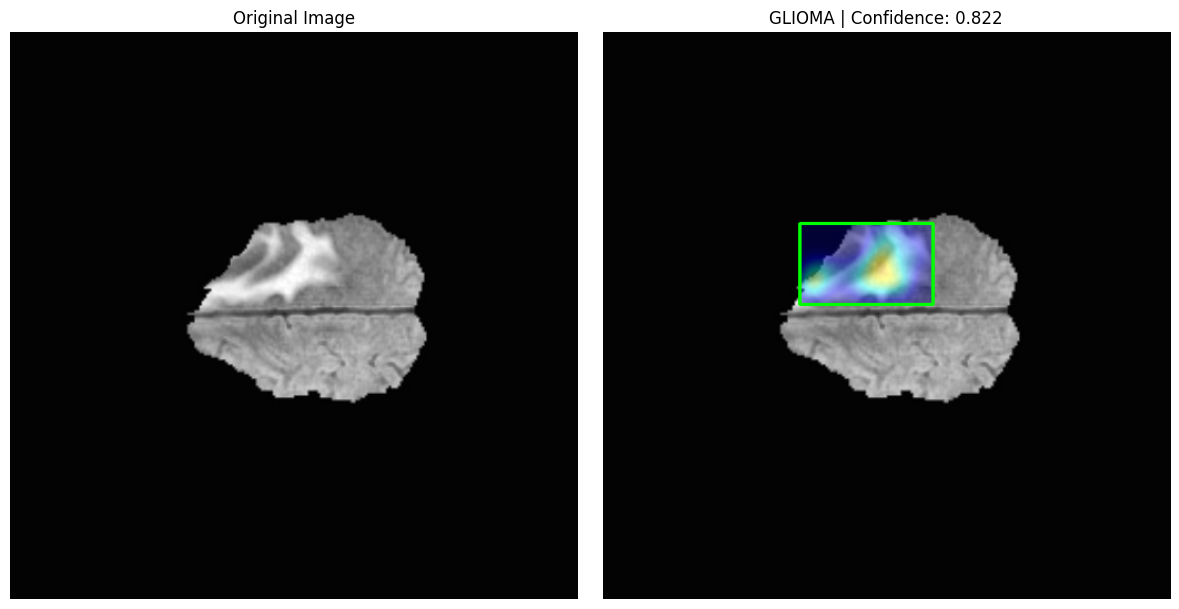


================ XAI INTERPRETATION ================

The model predicts GLIOMA with confidence 0.822.
The highlighted region inside the bounding box shows
localized importance contributing to the classification.
The tumor region covers approximately 3.34% of the image area.
The average attribution strength inside the box is 0.2018.

This indicates that the prediction is primarily driven
by features within the detected lesion area.




In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ============================================================
# CONFIGURATION
# ============================================================
MODEL_PATH = r"C:\Users\abhis\Documents\yolo_merge\runs\detect\runs\detect\yolov12n_safe_training\weights\best.pt"
IMAGE_PATH = r"C:\Users\abhis\Documents\yolo_merge\brain_merged_final_2\images\val\img_11.jpg"

PATCH_SIZE = 20
STRIDE = 8
GAUSS_SIGMA = 5
FINAL_SMOOTH = 6

# ============================================================

model = YOLO(MODEL_PATH)
model.to("cpu")

img_bgr = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# ------------------------------------------------------------
# BASE PREDICTION
# ------------------------------------------------------------
base = model(IMAGE_PATH, verbose=False)[0]

if base.boxes is None or len(base.boxes) == 0:
    print("❌ No tumor detected")
    raise SystemExit

box = base.boxes[0]
base_conf = float(box.conf[0])
cls_id = int(box.cls[0])
cls_name = model.names[cls_id]

x1, y1, x2, y2 = map(int, box.xyxy[0])

# ------------------------------------------------------------
# OCCLUSION ONLY INSIDE BBOX
# ------------------------------------------------------------
heatmap = np.zeros((h, w), dtype=np.float32)

for y in range(y1, y2 - PATCH_SIZE, STRIDE):
    for x in range(x1, x2 - PATCH_SIZE, STRIDE):

        occluded = img_bgr.copy()

        roi = occluded[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        roi_blur = cv2.GaussianBlur(roi, (0, 0), GAUSS_SIGMA)
        occluded[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = roi_blur

        result = model(occluded, verbose=False)[0]

        if result.boxes is None or len(result.boxes) == 0:
            conf = 0.0
        else:
            conf = float(result.boxes[0].conf[0])

        drop = base_conf - conf
        if drop > 0:
            heatmap[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += drop

# ------------------------------------------------------------
# NORMALIZE ONLY BBOX AREA
# ------------------------------------------------------------
roi = heatmap[y1:y2, x1:x2]

if roi.size > 0:
    roi = roi / (np.max(roi) + 1e-6)
    heatmap[y1:y2, x1:x2] = roi

heatmap = cv2.GaussianBlur(heatmap, (0, 0), FINAL_SMOOTH)

# Zero outside bbox strictly
mask = np.zeros_like(heatmap)
mask[y1:y2, x1:x2] = heatmap[y1:y2, x1:x2]
heatmap = mask

# ------------------------------------------------------------
# CREATE OVERLAY
# ------------------------------------------------------------
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = img.copy()
overlay[y1:y2, x1:x2] = cv2.addWeighted(
    img[y1:y2, x1:x2],
    0.6,
    heatmap_color[y1:y2, x1:x2],
    0.4,
    0
)

cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f"{cls_name.upper()} | Confidence: {base_conf:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SHORT XAI INTERPRETATION
# ------------------------------------------------------------

area_percent = ((x2-x1)*(y2-y1)) / (w*h) * 100
avg_heat = np.mean(heatmap[y1:y2, x1:x2])

print("\n================ XAI INTERPRETATION ================\n")
print(f"The model predicts {cls_name.upper()} with confidence {base_conf:.3f}.")
print(f"The highlighted region inside the bounding box shows")
print(f"localized importance contributing to the classification.")
print(f"The tumor region covers approximately {area_percent:.2f}% of the image area.")
print(f"The average attribution strength inside the box is {avg_heat:.4f}.")
print("\nThis indicates that the prediction is primarily driven")
print("by features within the detected lesion area.")
print("\n====================================================\n")


Selected Image: img_3786.jpg


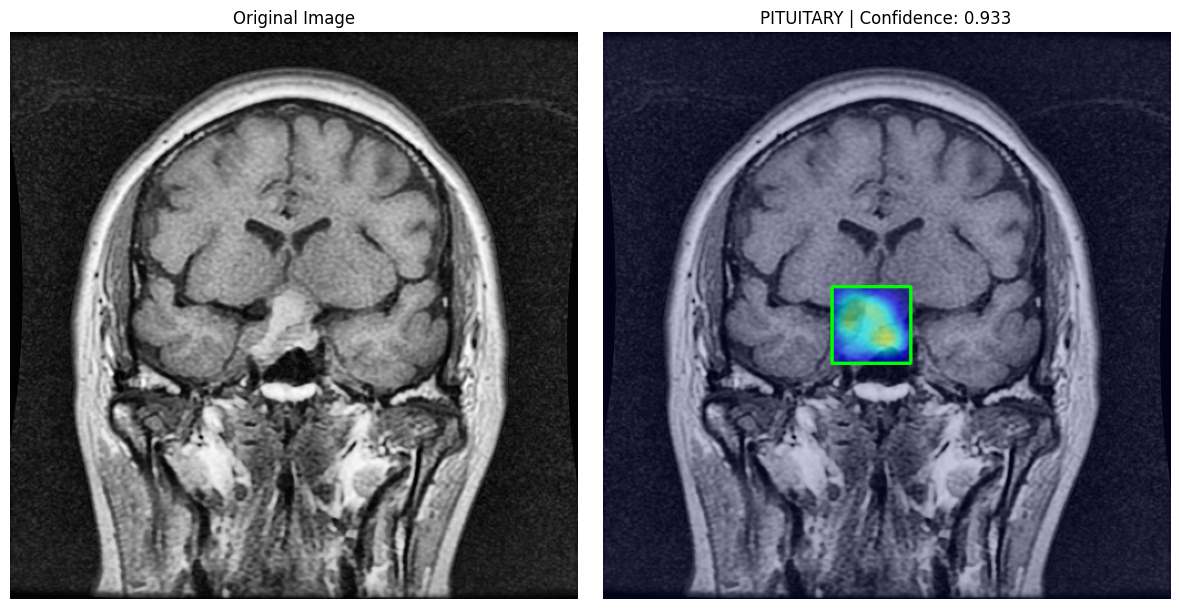


================ VLM INTERPRETATION ================

The model predicts PITUITARY with confidence 0.933.
The decision is primarily influenced by features located in the middle-central region of the brain.
The detected lesion occupies approximately 1.87% of the image area.
Attribution intensity inside the tumor region is 0.2831,
indicating that the model's prediction is mainly driven by localized structural abnormalities.




In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os
import random

# ============================================================
# CONFIGURATION
# ============================================================

MODEL_PATH = r"C:\Users\abhis\Documents\yolo_merge\runs\detect\runs\detect\yolov12n_safe_training\weights\best.pt"
TEST_FOLDER = r"C:\Users\abhis\Documents\yolo_merge\brain_merged_final_2\images\val"

PATCH_SIZE = 20
STRIDE = 8
GAUSS_SIGMA = 5
FINAL_SMOOTH = 6

# ============================================================

model = YOLO(MODEL_PATH)
model.to("cpu")

# ------------------------------------------------------------
# RANDOM IMAGE SELECTION
# ------------------------------------------------------------

image_files = [f for f in os.listdir(TEST_FOLDER)
               if f.lower().endswith((".jpg", ".png", ".jpeg"))]

if not image_files:
    print("❌ No images found in test folder.")
    raise SystemExit

random_image = random.choice(image_files)
IMAGE_PATH = os.path.join(TEST_FOLDER, random_image)

print(f"\nSelected Image: {random_image}")

# ------------------------------------------------------------
# LOAD IMAGE
# ------------------------------------------------------------

img_bgr = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# ------------------------------------------------------------
# BASE PREDICTION
# ------------------------------------------------------------

base = model(IMAGE_PATH, verbose=False)[0]

if base.boxes is None or len(base.boxes) == 0:
    print("❌ No tumor detected")
    raise SystemExit

box = base.boxes[0]
base_conf = float(box.conf[0])
cls_id = int(box.cls[0])
cls_name = model.names[cls_id]

x1, y1, x2, y2 = map(int, box.xyxy[0])

# ------------------------------------------------------------
# OCCLUSION XAI (ONLY INSIDE BBOX)
# ------------------------------------------------------------

heatmap = np.zeros((h, w), dtype=np.float32)

for y in range(y1, y2 - PATCH_SIZE, STRIDE):
    for x in range(x1, x2 - PATCH_SIZE, STRIDE):

        occluded = img_bgr.copy()
        roi = occluded[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        roi_blur = cv2.GaussianBlur(roi, (0, 0), GAUSS_SIGMA)
        occluded[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = roi_blur

        result = model(occluded, verbose=False)[0]

        if result.boxes is None or len(result.boxes) == 0:
            conf = 0.0
        else:
            conf = float(result.boxes[0].conf[0])

        drop = base_conf - conf
        if drop > 0:
            heatmap[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += drop

# Normalize strictly inside bbox
roi = heatmap[y1:y2, x1:x2]

if roi.size > 0:
    roi = roi / (np.max(roi) + 1e-6)
    heatmap_clean = np.zeros_like(heatmap)
    heatmap_clean[y1:y2, x1:x2] = roi
else:
    heatmap_clean = heatmap.copy()

heatmap_clean = cv2.GaussianBlur(heatmap_clean, (0, 0), FINAL_SMOOTH)

# ------------------------------------------------------------
# CREATE CLEAN VISUAL
# ------------------------------------------------------------

# Soft blue full-image tint
blue_layer = np.zeros_like(img)
blue_layer[:] = (0, 0, 120)
soft_background = cv2.addWeighted(img, 0.8, blue_layer, 0.2, 0)

heatmap_uint8 = np.uint8(255 * heatmap_clean)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = soft_background.copy()
overlay[y1:y2, x1:x2] = cv2.addWeighted(
    soft_background[y1:y2, x1:x2],
    0.4,
    heatmap_color[y1:y2, x1:x2],
    0.6,
    0
)

cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f"{cls_name.upper()} | Confidence: {base_conf:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# VLM-STYLE AUTO INTERPRETATION
# ------------------------------------------------------------

area_percent = ((x2 - x1) * (y2 - y1)) / (w * h) * 100
avg_heat = np.mean(heatmap_clean[y1:y2, x1:x2])

# Determine location
cx = (x1 + x2) / 2
cy = (y1 + y2) / 2

horizontal = "left" if cx < w/3 else "right" if cx > 2*w/3 else "central"
vertical = "upper" if cy < h/3 else "lower" if cy > 2*h/3 else "middle"

print("\n================ VLM INTERPRETATION ================\n")
print(f"The model predicts {cls_name.upper()} with confidence {base_conf:.3f}.")
print(f"The decision is primarily influenced by features located in the {vertical}-{horizontal} region of the brain.")
print(f"The detected lesion occupies approximately {area_percent:.2f}% of the image area.")
print(f"Attribution intensity inside the tumor region is {avg_heat:.4f},")
print("indicating that the model's prediction is mainly driven by localized structural abnormalities.")
print("\n====================================================\n")